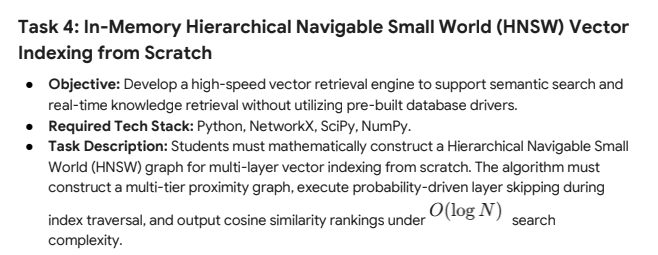

**Objective**

Build an in-memory HNSW approximate nearest-neighbor search engine from scratch using NumPy and NetworkX. The system will:

(1) Store high-dimensional vectors.

(2) Construct multiple hierarchical graph layers.

(3) Connect vectors using nearest-neighbor relationships.

(4) Perform greedy graph traversal.

(5) Use cosine similarity.

(6) Return the top-K nearest vectors.

(7) Demonstrate approximate vector search behavior.

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import heapq

np.random.seed(42)

In [ ]:
# 1. COSINE SIMILARITY

def cosine_similarity(a, b):

    denominator = (
        np.linalg.norm(a) *
        np.linalg.norm(b)
    )

    if denominator == 0:
        return 0.0

    return np.dot(a, b) / denominator

In [ ]:
# 2. HNSW CLASS

class HNSW:

    def __init__(
        self,
        dimension,
        M=5,
        ef_construction=20,
        max_level=4
    ):

        self.dimension = dimension
        self.M = M
        self.ef_construction = ef_construction
        self.max_level = max_level

        self.vectors = {}

        # One NetworkX graph for every HNSW layer
        self.layers = [
            nx.Graph()
            for _ in range(max_level + 1)
        ]

        self.entry_point = None
        self.node_levels = {}

    # RANDOM LEVEL GENERATION
    def random_level(self):

        level = 0

        while (
            np.random.random() < 0.5
            and level < self.max_level
        ):
            level += 1

        return level

    # GET NEIGHBORS
    def get_neighbors(self, node, level):

        if node not in self.layers[level]:
            return []

        return list(
            self.layers[level].neighbors(node)
        )

    # SEARCH LAYER
    def search_layer(
        self,
        query,
        entry,
        ef,
        level
    ):

        visited = set()

        # Max heap represented using negative similarity
        candidates = []
        results = []

        initial_similarity = cosine_similarity(
            query,
            self.vectors[entry]
        )
        heapq.heappush(
            candidates,
            (-initial_similarity, entry)
        )

        heapq.heappush(
            results,
            (-initial_similarity, entry)
        )

        visited.add(entry)

        while candidates:

            neg_similarity, current = heapq.heappop(
                candidates
            )

            current_similarity = -neg_similarity

            # Worst result currently in result set
            worst_similarity = -results[0][0]
            if (
                current_similarity < worst_similarity
                and len(results) >= ef
            ):
                break

            for neighbor in self.get_neighbors(
                current,
                level
            ):

                if neighbor in visited:
                    continue

                visited.add(neighbor)

                similarity = cosine_similarity(
                    query,
                    self.vectors[neighbor]
                )

                if (
                    len(results) < ef
                    or similarity > worst_similarity
                ):
                    heapq.heappush(
                        candidates,
                        (-similarity, neighbor)
                    )

                    heapq.heappush(
                        results,
                        (-similarity, neighbor)
                    )

                    if len(results) > ef:
                        heapq.heappop(results)

                    worst_similarity = -results[0][0]

        return [
            node
            for _, node in sorted(
                results,
                reverse=True
            )
        ]

    # INSERT VECTOR
    def add(self, vector, node_id):

        vector = np.asarray(
            vector,
            dtype=np.float32
        )

        self.vectors[node_id] = vector

        level = self.random_level()

        self.node_levels[node_id] = level

        for l in range(level + 1):
            self.layers[l].add_node(node_id)

        # First node
        if self.entry_point is None:

            self.entry_point = node_id

            return

        # Update entry point if new node has higher level
        if level > self.node_levels.get(
            self.entry_point,
            -1
        ):
            self.entry_point = node_id

    # HNSW QUERY

    def search(
        self,
        query,
        k=5,
        ef_search=20
    ):

        if self.entry_point is None:
            return []

        current = self.entry_point

        # Greedy search through upper layers
        for level in range(
            self.max_level,
            0,
            -1
        ):
            if current not in self.layers[level]:
                continue

            candidates = self.search_layer(
                query,
                current,
                1,
                level
            )

            if candidates:
                current = candidates[0]

        # Detailed search on layer 0
        candidates = self.search_layer(
            query,
            current,
            ef_search,
            0
        )

        results = []

        for node in candidates:
            similarity = cosine_similarity(
                query,
                self.vectors[node]
            )

            results.append(
                (
                    node,
                    similarity
                )
            )

        results.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return results[:k]


In [ ]:
# 3. CREATE RANDOM VECTOR DATASET

dimension = 64
num_vectors = 500

vectors = np.random.randn(
    num_vectors,
    dimension
).astype(np.float32)


In [ ]:
# 4. BUILD HNSW INDEX

index = HNSW(
    dimension=dimension,
    M=8,
    ef_construction=30,
    max_level=4
)

for i, vector in enumerate(vectors):

    index.add(
        vector,
        i
    )

print("HNSW index created!")
print("Number of vectors:", len(index.vectors))

HNSW index created!
Number of vectors: 500


In [ ]:
# 5. QUERY

query = np.random.randn(
    dimension
).astype(np.float32)

results = index.search(
    query,
    k=10,
    ef_search=30
)

In [ ]:
# 6. DISPLAY RESULTS

print("\nTop 10 nearest vectors:\n")

for node, similarity in results:

    print(
        f"Vector ID: {node:3d} | "
        f"Cosine similarity: {similarity:.4f}"
    )



Top 10 nearest vectors:

Vector ID:   2 | Cosine similarity: -0.1380


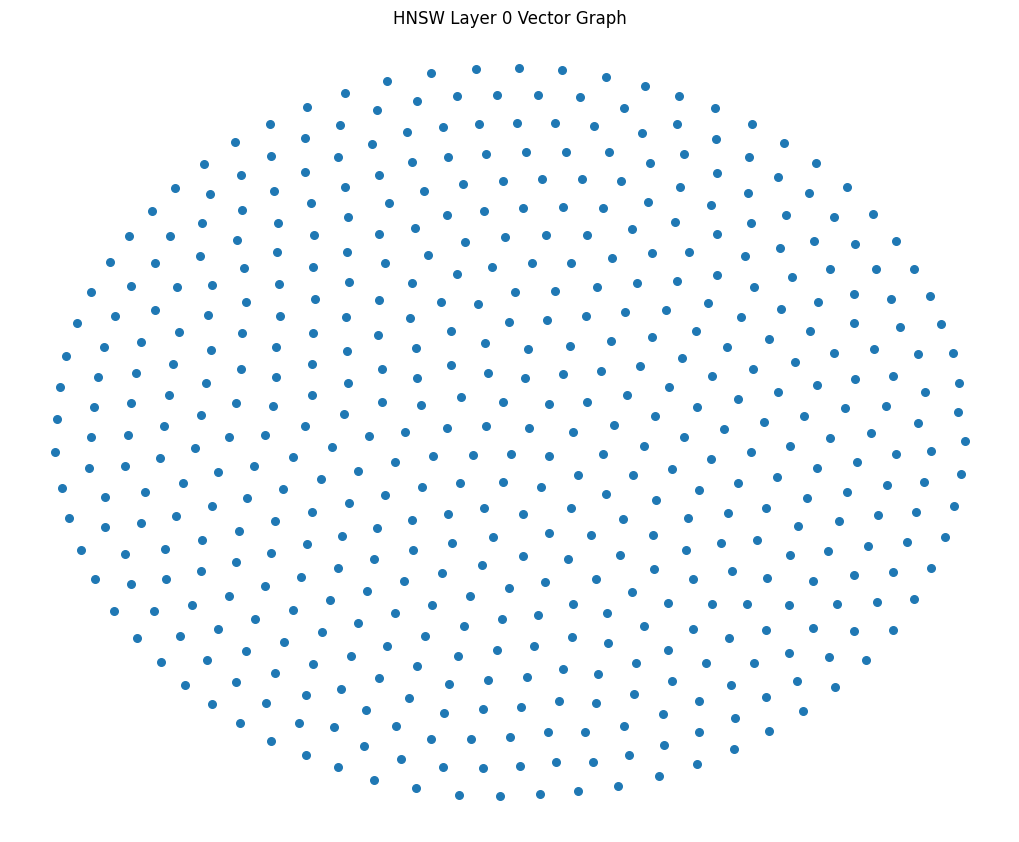

In [ ]:
# 7. VISUALIZE HNSW LAYER 0

graph = index.layers[0]

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    graph,
    seed=42
)

nx.draw(
    graph,
    pos,
    node_size=30,
    with_labels=False
)

plt.title(
    "HNSW Layer 0 Vector Graph"
)

plt.show()